In [67]:
import pandas as pd
import numpy as np
import MetaTrader5 as mt5
import os
from Trade.TerminalInfo import CTerminalInfo
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
seaborn.set_style("darkgrid")

### Initialize MetaTrader5

In [68]:
if not mt5.initialize():
    print("Failed to Initialize MetaTrade5, Error = ",mt5.last_error())
    mt5.shutdown()
    

terminal = CTerminalInfo() # similarly to CTerminalInfo from MQL5. For getting information about the MetaTrader5 app

## Importing the data

In [69]:
common_path = os.path.join(terminal.common_data_path(), "Files")
symbol = "XAUUSD"
timeframe = "PERIOD_D1"

df = pd.read_csv(os.path.join(common_path, f"Oscillators.{symbol}.{timeframe}.csv")) # the same naming pattern as the one used in the MQL5 script

# Identify max float value
max_float = np.finfo(float).max

# Replace all max float (double) values with NaN produced by preliminary indicator calculations
df = df.replace(max_float, np.nan)
df.dropna(inplace=True)
df["Time"] = pd.to_datetime(df["Time"], unit="s")

df.head()

,Time,Open,High,Low,Close,ATR,BearsPower,BullsPower,Chainkin,CCI,...,MACD SIGNAL_LINE,Momentum,OsMA,RSI,RVI MAIN_LINE,RVI SIGNAL_LINE,StochasticOscillator MAIN_LINE,StochasticOscillator SIGNAL_LINE,TEMA,WPR
0,2005-01-03,438.45,438.71,426.72,429.55,5.481429,-12.314215,-0.324215,-1079.046551,-51.013015,...,0.175727,99.870165,-0.582169,46.666555,-0.082596,0.018515,26.976532,32.920132,-0.000089,-85.144357
1,2005-01-04,429.52,430.18,423.71,427.51,5.450000,-13.677899,-7.207899,-1129.324384,-235.622347,...,-0.000779,98.615544,-1.252741,37.393138,-0.158362,-0.048541,22.158658,27.150101,-0.000190,-82.774252
2,2005-01-05,427.50,428.77,425.10,426.58,5.162143,-10.743913,-7.073913,-1496.644248,-196.837418,...,-0.247283,97.044402,-1.816758,35.666584,-0.227422,-0.119850,17.070979,22.068723,-0.000325,-86.990027
3,2005-01-06,426.31,427.85,420.17,421.37,5.234286,-13.606211,-5.926211,-3349.884147,-164.038728,...,-0.576309,97.480164,-2.194161,34.651526,-0.269634,-0.187300,14.096364,17.775334,-0.000482,-95.312500
4,2005-01-07,421.39,425.48,416.57,419.02,5.605000,-15.098181,-6.188181,-4970.426959,-168.301515,...,-1.015433,95.440750,-2.669414,30.754440,-0.305796,-0.243045,11.442611,14.203318,-0.000670,-91.609589


### Making the Target variable

In [70]:
lookahead = 5

df["future_close"] = df["Close"].shift(-lookahead)
new_df = df.dropna()

new_df["Direction"] = np.where(new_df["future_close"]>new_df["Close"], 1, -1) # if a the close value in the next bar(s)=lookahead is above the current close price, thats a long signal otherwise that's a short signal

In [71]:
from sklearn.model_selection import train_test_split

X = new_df.drop(columns=[
    "Time",
    "Open",
    "High",
    "Low",
    "Close",
    "future_close",
    "Direction"
])

y = new_df["Direction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [72]:
X_train.head()

,ATR,BearsPower,BullsPower,Chainkin,CCI,Demarker,Force,MACD MAIN_LINE,MACD SIGNAL_LINE,Momentum,OsMA,RSI,RVI MAIN_LINE,RVI SIGNAL_LINE,StochasticOscillator MAIN_LINE,StochasticOscillator SIGNAL_LINE,TEMA,WPR
3841,20.967857,-0.191879,27.908121,22895.106668,39.238354,0.694234,803186.261538,23.703731,25.581264,101.778947,-1.877533,61.614940,0.017835,0.019879,42.767355,43.567304,0.002555,-12.200957
2451,16.215000,-23.743521,18.126479,1099.653918,140.250557,0.467690,27286.773846,-1.667789,-6.830228,101.249828,5.162439,56.541307,0.219546,0.149307,64.554510,77.988691,-0.000746,-53.574102
2646,22.077143,5.822308,46.432308,7717.049271,94.655315,0.846880,352292.520000,8.066511,2.633330,104.475848,5.433181,59.070564,0.222363,0.207174,75.250523,76.982853,0.000501,-4.507866
1945,19.649286,2.699525,17.529525,42548.832710,88.084592,0.482666,-29008.800000,-4.199051,-8.070167,100.280289,3.871115,53.122452,0.059019,-0.008519,87.181588,86.940950,-0.000651,-31.359803
3425,12.080000,4.448291,14.868291,157068.583974,60.696698,0.696239,359097.730769,14.596714,14.886827,101.166612,-0.290113,66.144284,0.197705,0.183087,59.759960,44.945173,0.001775,-9.624292


### Finding the Best number of components for LGMM

In [73]:
from sklearn.mixture import GaussianMixture
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

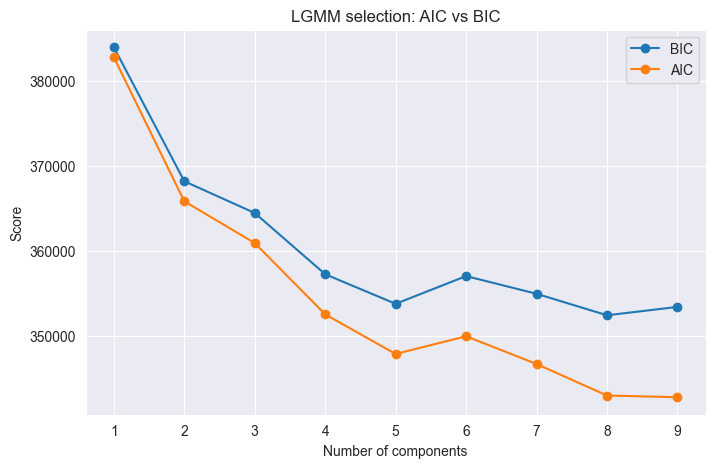

In [74]:
lowest_bic = np.inf
bic = []
aic = []
n_components_range = range(1, 10)

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X)
    bic.append(gmm.bic(X_train))
    aic.append(gmm.aic(X_train))
    if bic[-1] < lowest_bic:
        best_gmm = gmm
        lowest_bic = bic[-1]

# Plot the BIC and AIC scores
plt.figure(figsize=(8, 5))
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('Score')
plt.title('LGMM selection: AIC vs BIC')
plt.legend()
plt.grid(True)
plt.show()

### Gaussian Mixture Model

Extract latent features

In [75]:
components = 5 # according to the elbow point

gmm = GaussianMixture(n_components=components, covariance_type="full", random_state=42)
gmm.fit(X_train)

latent_features_train = gmm.predict_proba(X_train)
latent_features_test = gmm.predict_proba(X_test)

In [76]:
latent_features_train

array([[7.13771065e-10, 0.00000000e+00, 0.00000000e+00, 3.72728433e-02,
        9.62727156e-01],
       [9.82813682e-01, 1.36818981e-30, 0.00000000e+00, 3.97668063e-07,
        1.71859202e-02],
       [5.80973896e-03, 0.00000000e+00, 0.00000000e+00, 9.93114912e-01,
        1.07534866e-03],
       ...,
       [1.43498631e-03, 0.00000000e+00, 0.00000000e+00, 2.66044193e-52,
        9.98565014e-01],
       [9.99942834e-01, 4.44108141e-69, 0.00000000e+00, 3.74722695e-43,
        5.71659198e-05],
       [1.39530764e-01, 1.34535625e-41, 0.00000000e+00, 8.60468881e-01,
        3.54737669e-07]], shape=(3756, 5))

Saving LGMM to ONNX

In [77]:
# Define input type (shape should match your training data)
initial_type = [("float_input", FloatTensorType([None, X_train.shape[1]]))]

# Convert the pipeline to ONNX format
onnx_model = convert_sklearn(gmm, initial_types=initial_type)

# Save the model to a file
with open(os.path.join(common_path, f"LGMM.{symbol}.{timeframe}.onnx"), "wb") as f:
    f.write(onnx_model.SerializeToString())


In [78]:
latent_features_train_df = pd.DataFrame(latent_features_train, columns=[f"LATENT_FEATURE_{i}" for i in range(latent_features_train.shape[1])])
latent_features_test_df = pd.DataFrame(latent_features_test, columns=[f"LATENT_FEATURE_{i}" for i in range(latent_features_test.shape[1])])

In [79]:
latent_features_train_df

,LATENT_FEATURE_0,LATENT_FEATURE_1,LATENT_FEATURE_2,LATENT_FEATURE_3,LATENT_FEATURE_4
0,7.137711e-10,0.000000e+00,0.0,3.727284e-02,9.627272e-01
1,9.828137e-01,1.368190e-30,0.0,3.976681e-07,1.718592e-02
2,5.809739e-03,0.000000e+00,0.0,9.931149e-01,1.075349e-03
3,9.999905e-01,4.430747e-198,0.0,5.543514e-09,9.476854e-06
4,3.049181e-03,0.000000e+00,0.0,9.969453e-01,5.535803e-06
...,...,...,...,...,...
3751,2.007429e-01,0.000000e+00,0.0,5.570708e-60,7.992571e-01
3752,6.194358e-02,9.380290e-01,0.0,5.552962e-21,2.744208e-05
3753,1.434986e-03,0.000000e+00,0.0,2.660442e-52,9.985650e-01
3754,9.999428e-01,4.441081e-69,0.0,3.747227e-43,5.716592e-05


In [80]:
all_columns = X_train.columns.tolist() + latent_features_train_df.columns.tolist()

X_latent_train_arr = np.hstack([X_train, latent_features_train_df])
X_latent_test_arr = np.hstack([X_test, latent_features_test_df])

X_Train_latent = pd.DataFrame(X_latent_train_arr, columns=all_columns)
X_Test_latent = pd.DataFrame(X_latent_test_arr, columns=all_columns)

X_Train_latent.columns

Index(['ATR', 'BearsPower', 'BullsPower', 'Chainkin', 'CCI', 'Demarker',
       'Force', 'MACD MAIN_LINE', 'MACD SIGNAL_LINE', 'Momentum', 'OsMA',
       'RSI', 'RVI MAIN_LINE', 'RVI SIGNAL_LINE',
       'StochasticOscillator MAIN_LINE', 'StochasticOscillator SIGNAL_LINE',
       'TEMA', 'WPR', 'LATENT_FEATURE_0', 'LATENT_FEATURE_1',
       'LATENT_FEATURE_2', 'LATENT_FEATURE_3', 'LATENT_FEATURE_4'],
      dtype='object')

### Random forest model alongside LGMM

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights_dict = dict(zip(classes, weights))

params = {
    "n_estimators": 100,
    "min_samples_split": 2,
    "max_depth": 10,
    "max_leaf_nodes": 10,
    "criterion": "gini",
    "random_state": 42
}

model = RandomForestClassifier(**params, class_weight=class_weights_dict)

model.fit(X_Train_latent, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,10
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
from sklearn.metrics import classification_report

In [83]:
y_train_pred = model.predict(X_Train_latent)

print("Train classification report\n", classification_report(y_train, y_train_pred))

y_test_pred = model.predict(X_Test_latent)

print("Test classification report\n", classification_report(y_test, y_test_pred))

Train classification report
               precision    recall  f1-score   support

          -1       0.56      0.70      0.62      1706
           1       0.69      0.54      0.61      2050

    accuracy                           0.61      3756
   macro avg       0.62      0.62      0.61      3756
weighted avg       0.63      0.61      0.61      3756

Test classification report
               precision    recall  f1-score   support

          -1       0.46      0.61      0.52       392
           1       0.63      0.48      0.55       548

    accuracy                           0.54       940
   macro avg       0.55      0.55      0.53       940
weighted avg       0.56      0.54      0.54       940



### Saving RFC to ONNX

In [84]:
# Define input type (shape should match your training data)
initial_type = [("float_input", FloatTensorType([None, X_Train_latent.shape[1]]))]

# Convert the pipeline to ONNX format
onnx_model = convert_sklearn(model, initial_types=initial_type)

# Save the model to a file
with open(os.path.join(common_path, f"rfc.{symbol}.{timeframe}.onnx"), "wb") as f:
    f.write(onnx_model.SerializeToString())

### Feature Importance

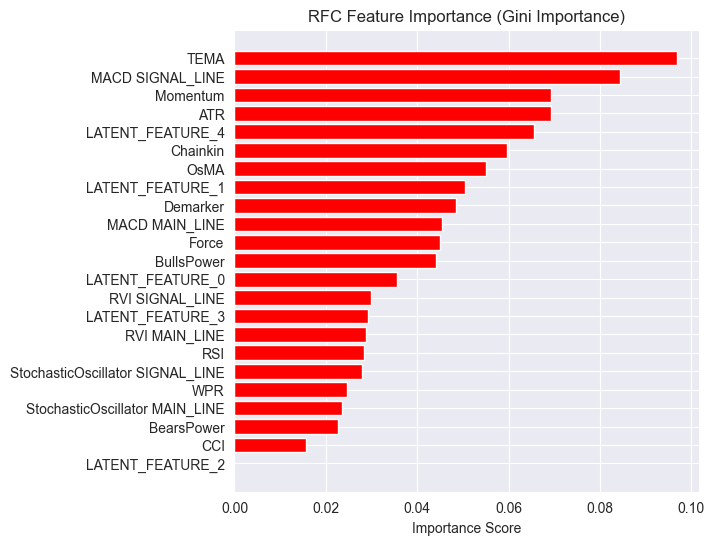

In [85]:
importances = model.feature_importances_
feature_names = X_Train_latent.columns if hasattr(X_Train_latent, 'columns') else [f'feature_{i}' for i in range(X_Train_latent.shape[1])]

# Create DataFrame and sort
importance_df = pd.DataFrame({'feature': all_columns, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(6, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='red')
plt.title('RFC Feature Importance (Gini Importance)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Most important on top
plt.show()